<a href="https://colab.research.google.com/github/agisnarevaldo/xai_lime_vs_shap/blob/main/notebooks/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — IndoBERT Fine-tuning: Sentiment Analysis (3-class)

Fine-tuning `indobenchmark/indobert-base-p1` on Tokopedia iPhone 17 reviews.

**Labels:** Positif (0) · Negatif (1) · Netral (2)  
**Dataset:** `data/processed/tokopedia_reviews_clean.csv` (1556 rows)  
**Distribution:** Positif≈1495, Negatif≈49, Netral≈12 → class weights to handle imbalance

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**git clone**

In [ ]:
import os
import shutil
import subprocess

REPO_URL = "https://github.com/agisnarevaldo/xai_lime_vs_shap.git"
REPO_DIR = "/content/xai_lime_vs_shap"

def run(cmd):
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}")
    return result

if os.path.isdir(REPO_DIR):
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        run(["git", "-C", REPO_DIR, "pull", "--ff-only"])
    else:
        shutil.rmtree(REPO_DIR)
        run(["git", "clone", REPO_URL, REPO_DIR])
else:
    run(["git", "clone", REPO_URL, REPO_DIR])

os.chdir(REPO_DIR)
print("CWD:", os.getcwd())
print("Root contents:", os.listdir("."))

$ git clone https://github.com/agisnarevaldo/xai_lime_vs_shap.git /content/xai_lime_vs_shap
Cloning into '/content/xai_lime_vs_shap'...

CWD: /content/xai_lime_vs_shap
Root contents: ['README.md', 'merge_data.py', '.git', 'full_scrape.py', 'quick_check_new_urls.py', 'merge_new_low_ratings.py', 'scrape_new_urls_deep.py', 'analyze_reviews.py', '.gitignore', 'scrape.ipynb', 'link.txt', 'scrape_additional.py', 'merge_all.py', 'promising_urls.txt', 'config', '.github', 'scrape_low_ratings.py', 'src', 'data', 'scraper.py', 'notebooks']


In [2]:
## 0. Google Colab Setup
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages …")
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_PROJECT = "/content/xai_lime_vs_shap"
    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)

    import subprocess
    # Added imbalanced-learn for oversampling
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "transformers", "torch", "datasets", "scikit-learn",
         "accelerate", "lime", "shap", "imbalanced-learn"],
        check=True,
    )
    print("Packages ready.")

Google Colab detected — mounting Drive & installing packages …
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Packages ready.


In [5]:
## 1. Imports & Config
import os, warnings, json
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


def find_project_root() -> Path:
    """Find repository root robustly across VS Code / Jupyter / Colab."""
    markers = ["data", "notebooks", "src"]
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path("/content/xai_lime_vs_shap"),
    ]

    for candidate in candidates:
        if all((candidate / m).exists() for m in markers):
            return candidate

    # Fallback to current directory if markers are not found
    return Path.cwd()


PROJECT_ROOT = find_project_root()
DATA_PATH = Path("/content/tokopedia_reviews_binary.csv") # Corrected data path
MODEL_DIR = PROJECT_ROOT / "outputs" / "indobert_sentiment"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Make sure project folder contains tokopedia_reviews_binary.csv"
    )

# Hyperparameters
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Project root: /content
Data path: /content/tokopedia_reviews_binary.csv
Device: cuda
PyTorch: 2.10.0+cu128


In [23]:
## 2. Load & Prepare Data with Oversampling
from imblearn.over_sampling import RandomOverSampler
from sklearn.utils.class_weight import compute_class_weight

df = pd.read_csv(DATA_PATH)
LABEL2ID = {"Positif": 0, "Negatif": 1, "Netral": 1}
ID2LABEL = {0: "Positif", 1: "Non-Positif"}

df["label"] = df["sentiment_label"].map(LABEL2ID)
df = df.dropna(subset=["review_text_clean", "label"])
df["label"] = df["label"].astype(int)

# Initial Split
X = df[["review_text_clean"]]
y = df["label"]

X_train_raw, X_tmp, y_train_raw, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# Calculate class weights based on the original imbalanced training set
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float).to(DEVICE)
print(f"Class weights: {class_weights}")

# Assign X_train and y_train directly from raw training data
X_train = X_train_raw["review_text_clean"].values
y_train = y_train_raw.values

# Convert others to values
X_val = X_val["review_text_clean"].values
X_test = X_test["review_text_clean"].values
y_val = y_val.values
y_test = y_test.values

print(f"Original Train size: {len(X_train_raw)}")
print(f"Train size (without oversampling): {len(X_train)}")
print("\nTrain Label distribution (without oversampling):")
print(pd.Series(y_train).value_counts().rename(index=ID2LABEL))


Class weights: tensor([ 0.5206, 12.6628], device='cuda:0')
Original Train size: 1089
Train size (without oversampling): 1089

Train Label distribution (without oversampling):
Positif        1046
Non-Positif      43
Name: count, dtype: int64


In [24]:
## 3. Tokenizer & Dataset class

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

Tokenizer: indobenchmark/indobert-base-p1
Train batches: 69  Val batches: 15


In [25]:
## 4. Model Setup (Oversampled Version)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

# Loss function with class weights
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)
print(f"Model ready with balanced training data and weighted loss.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready with balanced training data and weighted loss.


In [26]:
## 5. Training Loop

def eval_model(loader, model, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return avg_loss, acc, all_preds, all_labels


history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for step, batch in enumerate(train_loader, 1):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        if step % 20 == 0:
            print(f"  Epoch {epoch} step {step}/{len(train_loader)} loss={loss.item():.4f}")

    avg_train = train_loss / len(train_loader)
    val_loss, val_acc, _, _ = eval_model(val_loader, model, loss_fn, DEVICE)
    history["train_loss"].append(avg_train)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch}/{EPOCHS} — train_loss={avg_train:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}\n")

print("Training complete.")

  Epoch 1 step 20/69 loss=1.1945
  Epoch 1 step 40/69 loss=0.0547
  Epoch 1 step 60/69 loss=0.0081
Epoch 1/3 — train_loss=0.8088  val_loss=0.5475  val_acc=0.9657

  Epoch 2 step 20/69 loss=1.0420
  Epoch 2 step 40/69 loss=0.0081
  Epoch 2 step 60/69 loss=0.2543
Epoch 2/3 — train_loss=0.2800  val_loss=0.3857  val_acc=0.9785

  Epoch 3 step 20/69 loss=0.0012
  Epoch 3 step 40/69 loss=0.0010
  Epoch 3 step 60/69 loss=0.0022
Epoch 3/3 — train_loss=0.0584  val_loss=0.4669  val_acc=0.9828

Training complete.


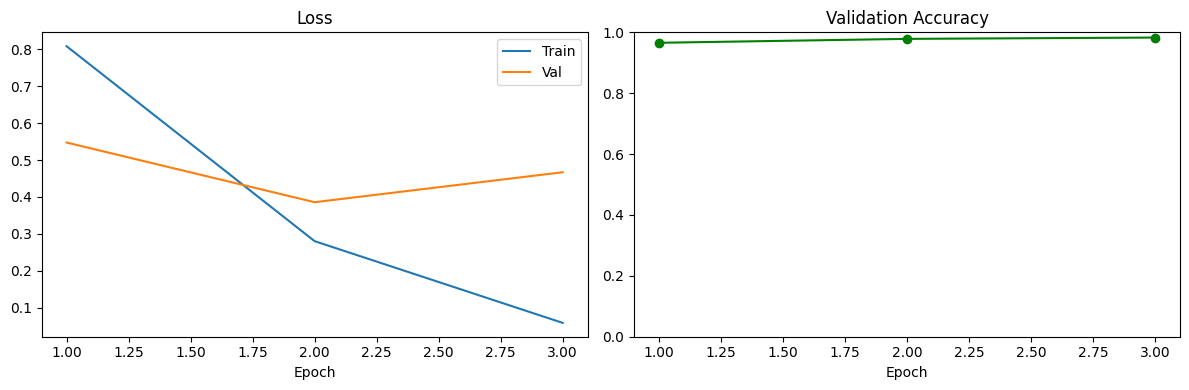

In [27]:
## 6. Training Curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history["train_loss"], label="Train")
axes[0].plot(epochs_x, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_x, history["val_acc"], color="green", marker="o")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1)

plt.tight_layout()
(PROJECT_ROOT / "outputs" / "figures").mkdir(parents=True, exist_ok=True)
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "03_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [28]:
## 7. Evaluation on Test Set

test_loss, test_acc, test_preds, test_labels = eval_model(test_loader, model, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}  Test Accuracy: {test_acc:.4f}\n")

target_names = ["Positif", "Non-Positif"]
report = classification_report(test_labels, test_preds, target_names=target_names, zero_division=0)
print(report)

# Save report
(PROJECT_ROOT / "outputs" / "reports").mkdir(parents=True, exist_ok=True)
with open(PROJECT_ROOT / "outputs" / "reports" / "03_classification_report.txt", "w") as f:
    f.write(report)


Test Loss: 0.9309  Test Accuracy: 0.9658

              precision    recall  f1-score   support

     Positif       0.97      0.99      0.98       225
 Non-Positif       0.60      0.33      0.43         9

    accuracy                           0.97       234
   macro avg       0.79      0.66      0.71       234
weighted avg       0.96      0.97      0.96       234



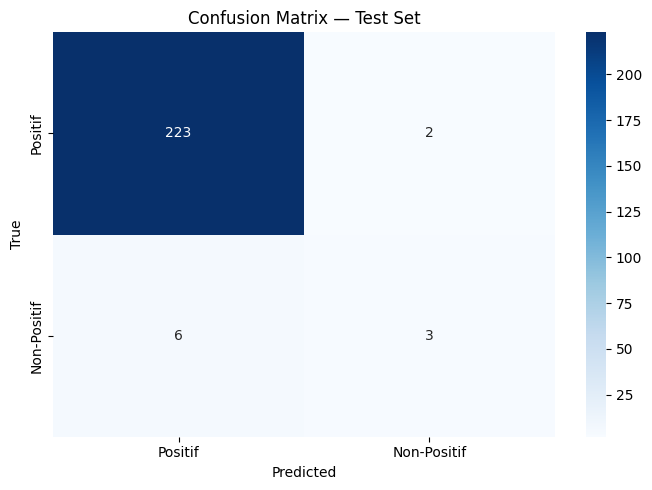

In [29]:
## 8. Confusion Matrix

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "03_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 9.1 Threshold Adjustment for Imbalanced Classes

Untuk meningkatkan *recall* pada kelas minoritas ('Non-Positif'), kita dapat menyesuaikan ambang batas klasifikasi. Secara _default_, model mengklasifikasikan sampel ke suatu kelas jika probabilitas prediksinya lebih besar dari 0.5. Dengan menurunkan ambang batas untuk kelas 'Non-Positif', kita membuat model lebih 'sensitif' terhadap kelas tersebut, yang diharapkan akan meningkatkan *recall* (jumlah True Positives) dengan potensi menurunkan *precision*.

Mari kita coba ambang batas 0.2 untuk kelas 'Non-Positif'.


Evaluation with custom threshold (0.2) for 'Non-Positif' class:
              precision    recall  f1-score   support

     Positif       0.97      0.99      0.98       225
 Non-Positif       0.50      0.33      0.40         9

    accuracy                           0.96       234
   macro avg       0.74      0.66      0.69       234
weighted avg       0.96      0.96      0.96       234



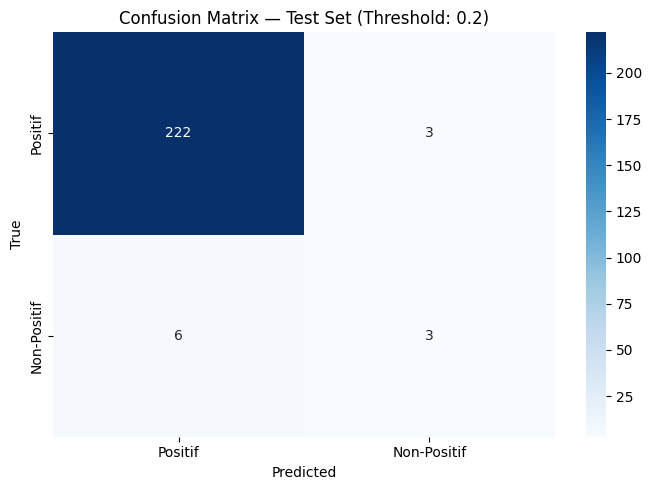

In [30]:
from torch.nn.functional import softmax

def get_probabilities_and_labels(loader, model, device):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probabilities = softmax(outputs.logits, dim=1)
            all_probs.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_probs), np.array(all_labels)

# Get probabilities and true labels for the test set
test_probs, true_test_labels = get_probabilities_and_labels(test_loader, model, DEVICE)

# Define the custom threshold for the 'Non-Positif' class (index 1)
# The default threshold is 0.5. Lowering it makes the model more likely to predict 'Non-Positif'.
CUSTOM_THRESHOLD = 0.2 # You can experiment with different values

# Generate new predictions based on the custom threshold
# If probability of 'Non-Positif' (index 1) is >= CUSTOM_THRESHOLD, predict 'Non-Positif' (1)
# Otherwise, predict 'Positif' (0)
custom_test_preds = np.where(test_probs[:, 1] >= CUSTOM_THRESHOLD, 1, 0)

print(f"\nEvaluation with custom threshold ({CUSTOM_THRESHOLD}) for 'Non-Positif' class:")

# Re-calculate and print the classification report
report_custom = classification_report(
    true_test_labels, custom_test_preds, target_names=target_names, zero_division=0
)
print(report_custom)

# Save report with custom threshold
(PROJECT_ROOT / "outputs" / "reports").mkdir(parents=True, exist_ok=True)
with open(PROJECT_ROOT / "outputs" / "reports" / "03_classification_report_custom_threshold.txt", "w") as f:
    f.write(report_custom)

# Re-calculate and plot the confusion matrix
cm_custom = confusion_matrix(true_test_labels, custom_test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix — Test Set (Threshold: {CUSTOM_THRESHOLD})")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "03_confusion_matrix_custom_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
## 9. Save Model & Tokenizer

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

# Save label map for notebook 04
with open(MODEL_DIR / "label_map.json", "w") as f:
    json.dump({"id2label": ID2LABEL, "label2id": LABEL2ID}, f, indent=2)

print(f"Model saved → {MODEL_DIR}")
print("Contents:", list(MODEL_DIR.glob("*")))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved → /content/outputs/indobert_sentiment
Contents: [PosixPath('/content/outputs/indobert_sentiment/model.safetensors'), PosixPath('/content/outputs/indobert_sentiment/tokenizer.json'), PosixPath('/content/outputs/indobert_sentiment/config.json'), PosixPath('/content/outputs/indobert_sentiment/label_map.json'), PosixPath('/content/outputs/indobert_sentiment/tokenizer_config.json')]
